In [4]:
# === Notebook Cell 1: settings & functions ====================================
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# scikit-learn が使えるならそれを利用（無ければフォールバック実装を使用）
try:
    from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, adjusted_mutual_info_score
    _SK_OK = True
except Exception:
    _SK_OK = False

# ==== パス設定（必要に応じて変更してください） ====
OH_DIR = Path("/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/OH/05_filtered_rows_20251027_203012")
FP_DIR = Path("/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/FP/05_filtered_rows_20251027_203141")
OUTDIR = Path("/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/plots_var")

# ==== 自動検出の候補 ====
_NAME_COL_CANDIDATES = ["variable","var","name","feature","Feature","column","col","field"]
_LABEL_COL_PRIORS    = ["cluster","label","assign","assignment","cluster_label","clusterid","cluster_id","k_label","k"]

def detect_name_col(df: pd.DataFrame) -> str:
    # 変数名の列を推定
    for c in df.columns:
        if str(c).strip() in _NAME_COL_CANDIDATES:
            return c
        if str(c).strip().lower() in [x.lower() for x in _NAME_COL_CANDIDATES]:
            return c
    return df.columns[0]

def detect_label_col(df: pd.DataFrame, name_col: str) -> str:
    # クラスタラベルの列を推定
    for p in _LABEL_COL_PRIORS:
        for c in df.columns:
            if str(c).strip().lower() == p:
                return c
    candidates = [c for c in df.columns if c != name_col]
    n = len(df)
    best, score = None, -1
    for c in candidates:
        u = df[c].nunique(dropna=True)
        is_intlike = pd.api.types.is_integer_dtype(df[c]) or pd.api.types.is_categorical_dtype(df[c])
        s = (1 if is_intlike else 0) + (1 if 2 <= u <= max(2, n//2) else 0)
        if s > score:
            best, score = c, s
    return best

def load_assignment(path: Path):
    """CSVを読み、(name,label) の2列DataFrameを返す"""
    df = pd.read_csv(path)
    name_col = detect_name_col(df)
    lab_col  = detect_label_col(df, name_col)
    if lab_col is None:
        raise RuntimeError(f"クラスタラベル列が検出できませんでした: {path}")
    names  = df[name_col].astype(str).str.strip()
    labels = df[lab_col].astype(str).str.strip()
    return pd.DataFrame({"name": names, "label": labels}), name_col, lab_col

# ファイル名から (mode,index,side) を抽出
_FN_RE = re.compile(r"ClusterAssign_(?P<mode>top3|cumeig)_(?P<index>[^_]+)_(?P<side>OH|FP)_", re.IGNORECASE)

def parse_tag(fpath: Path):
    m = _FN_RE.search(fpath.name)
    if not m:
        return None
    mode  = m.group("mode").lower()
    index = m.group("index")
    side  = m.group("side").upper()
    return mode, index, side

# === メトリクス（フォールバック） ===
def _ari_fallback(y_true, y_pred):
    yt = pd.Series(y_true).astype("category").cat.codes.values
    yp = pd.Series(y_pred).astype("category").cat.codes.values
    cont = pd.crosstab(pd.Series(yt), pd.Series(yp)).values
    nij = cont
    ai = nij.sum(axis=1)
    bj = nij.sum(axis=0)
    n = nij.sum()
    def comb2(x): x = np.asarray(x, dtype=np.int64); return (x*(x-1))//2
    sum_comb_c = comb2(nij).sum()
    sum_comb_a = comb2(ai).sum()
    sum_comb_b = comb2(bj).sum()
    total_comb = comb2(n)
    expected_index = (sum_comb_a * sum_comb_b) / total_comb if total_comb > 0 else 0.0
    max_index = 0.5*(sum_comb_a + sum_comb_b)
    index = sum_comb_c
    denom = (max_index - expected_index)
    return float((index - expected_index) / denom) if denom != 0 else 0.0

def _entropy(p):
    p = np.asarray(p, dtype=float)
    p = p[p>0]
    return float(-(p*np.log(p)).sum()) if p.size else 0.0

def _nmi_fallback(y_true, y_pred):
    yt = pd.Series(y_true).astype("category").cat.codes.values
    yp = pd.Series(y_pred).astype("category").cat.codes.values
    cont = pd.crosstab(pd.Series(yt), pd.Series(yp)).values.astype(float)
    n = cont.sum()
    if n == 0:
        return 0.0
    pi = cont.sum(axis=1)/n
    pj = cont.sum(axis=0)/n
    pij = cont/n
    with np.errstate(divide='ignore', invalid='ignore'):
        logt = np.log(pij/(pi[:,None]*pj[None,:]))
        logt[~np.isfinite(logt)] = 0.0
        mi = float((pij*logt).sum())
    h1 = _entropy(pi); h2 = _entropy(pj)
    denom = (h1+h2)/2.0 if (h1+h2)>0 else 1.0
    return float(mi/denom) if denom>0 else 0.0

def _ami_fallback(y_true, y_pred):
    # sklearn 不在時は NMI を近似として返す
    return _nmi_fallback(y_true, y_pred)

def compute_metrics_from_frames(df_oh, df_fp):
    """(name,label)×2から、共通nameで揃えて ARI/NMI/AMI を返す"""
    common = sorted(set(df_oh["name"]).intersection(set(df_fp["name"])))
    if len(common) == 0:
        raise RuntimeError("共通変数名が 0 件です。フィルタ済みCSVの変数名が一致しているか確認してください。")
    y_oh = df_oh.set_index("name").loc[common]["label"].astype(str).values
    y_fp = df_fp.set_index("name").loc[common]["label"].astype(str).values
    kA = int(pd.Series(y_oh).nunique())
    kB = int(pd.Series(y_fp).nunique())
    if kA < 2 or kB < 2:
        raise RuntimeError(f"クラスタ数が不足 (OH k={kA}, FP k={kB})。")
    if _SK_OK:
        ARI = float(adjusted_rand_score(y_oh, y_fp))
        NMI = float(normalized_mutual_info_score(y_oh, y_fp))
        AMI = float(adjusted_mutual_info_score(y_oh, y_fp))
    else:
        ARI = _ari_fallback(y_oh, y_fp)
        NMI = _nmi_fallback(y_oh, y_fp)
        AMI = _ami_fallback(y_oh, y_fp)
    return {"n_common_vars": len(common), "kA_OH": kA, "kB_FP": kB, "ARI": ARI, "NMI": NMI, "AMI": AMI}

def plot_bars(df, metric, outdir):
    """
    df: columns = ['mode','index','metric_value']
    同じ 'index' 内で top3 / cumeig の 2本バーを描く
    """
    if df.empty: 
        return
    outdir.mkdir(parents=True, exist_ok=True)
    idxs  = sorted(df["index"].unique())
    modes = ["top3","cumeig"]

    # データ行列を作る（行: index, 列: mode）
    vals = []
    for ind in idxs:
        row = []
        for m in modes:
            v = df.loc[(df["index"]==ind) & (df["mode"]==m), "metric_value"]
            row.append(float(v.values[0]) if len(v)==1 else np.nan)
        vals.append(row)
    vals = np.array(vals)
    x = np.arange(len(idxs))
    width = 0.35

    plt.figure()
    plt.bar(x - width/2, vals[:,0], width, label="top3")
    plt.bar(x + width/2, vals[:,1], width, label="cumeig")
    plt.xticks(x, idxs, rotation=45, ha="right")
    plt.ylabel(metric)
    plt.xlabel("NbClust index")
    plt.title(f"{metric} (OH vs FP variable labels)")
    plt.legend()
    plt.tight_layout()
    outdir.mkdir(parents=True, exist_ok=True)
    plt.savefig(outdir / f"{metric}_bars.png", dpi=300)
    plt.savefig(outdir / f"{metric}_bars.pdf")
    plt.close()

def index_files_by_tag(directory: Path, side_label: str):
    """
    ディレクトリ配下の ClusterAssign_*_{side_label}_*.csv を列挙して、
    key=(mode,index,side) -> path の dict を返す
    """
    files = sorted(directory.glob(f"ClusterAssign_*_{side_label}_*.csv"))
    out = {}
    for f in files:
        t = parse_tag(f)
        if not t:  # 非対象ファイルはスキップ
            continue
        mode, index, side = t
        out[(mode,index,side)] = f
    return out

In [5]:
# === Notebook Cell 2: run ======================================================
OUTDIR.mkdir(parents=True, exist_ok=True)

oh_map = index_files_by_tag(OH_DIR, "OH")
fp_map = index_files_by_tag(FP_DIR, "FP")

# OH/FP が両方揃う (mode,index) のみ対象
pairs = []
for (mode,index,side) in oh_map.keys():
    if side != "OH":
        continue
    if (mode,index,"FP") in fp_map:
        pairs.append((mode,index))

if not pairs:
    raise SystemExit("OH と FP の両方が揃う (mode,index) の組が見つかりません。")

rows = []
for mode,index in sorted(set(pairs)):
    f_oh = oh_map[(mode,index,"OH")]
    f_fp = fp_map[(mode,index,"FP")]
    df_oh, namecol_oh, labcol_oh = load_assignment(f_oh)
    df_fp, namecol_fp, labcol_fp = load_assignment(f_fp)
    try:
        metr = compute_metrics_from_frames(df_oh, df_fp)
        rows.append({
            "mode": mode, "index": index,
            "n_common_vars": metr["n_common_vars"],
            "kA_OH": metr["kA_OH"], "kB_FP": metr["kB_FP"],
            "ARI": metr["ARI"], "NMI": metr["NMI"], "AMI": metr["AMI"],
            "OH_file": str(f_oh), "FP_file": str(f_fp),
            "OH_name_col": namecol_oh, "OH_label_col": labcol_oh,
            "FP_name_col": namecol_fp, "FP_label_col": labcol_fp
        })
    except Exception as e:
        rows.append({
            "mode": mode, "index": index, "error": str(e),
            "OH_file": str(f_oh), "FP_file": str(f_fp)
        })

res = pd.DataFrame(rows).sort_values(["index","mode"]).reset_index(drop=True)
display(res)

# まとめCSVの保存
summary_csv = OUTDIR / "metrics_ohfp_by_mode_index.csv"
res.to_csv(summary_csv, index=False, encoding="utf-8-sig")
print("Saved summary:", summary_csv)

# 可視化（top3/cumeig の独立棒）
ok = res.dropna(subset=["ARI","NMI","AMI"])
for metric in ["ARI","NMI","AMI"]:
    sub = ok[["mode","index",metric]].rename(columns={metric:"metric_value"})
    if not sub.empty:
        plot_bars(sub, metric, OUTDIR)
print("Saved plots to:", OUTDIR)

,mode,index,error,OH_file,FP_file
0,cumeig,ch,共通変数名が 0 件です。フィルタ済みCSVの変数名が一致しているか確認してください。,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...
1,top3,ch,共通変数名が 0 件です。フィルタ済みCSVの変数名が一致しているか確認してください。,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...
2,cumeig,db,共通変数名が 0 件です。フィルタ済みCSVの変数名が一致しているか確認してください。,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...
3,top3,db,共通変数名が 0 件です。フィルタ済みCSVの変数名が一致しているか確認してください。,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...
4,cumeig,dunn,共通変数名が 0 件です。フィルタ済みCSVの変数名が一致しているか確認してください。,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...
5,top3,dunn,共通変数名が 0 件です。フィルタ済みCSVの変数名が一致しているか確認してください。,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...
6,cumeig,gap,共通変数名が 0 件です。フィルタ済みCSVの変数名が一致しているか確認してください。,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...
7,top3,gap,共通変数名が 0 件です。フィルタ済みCSVの変数名が一致しているか確認してください。,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...
8,cumeig,ptbiserial,共通変数名が 0 件です。フィルタ済みCSVの変数名が一致しているか確認してください。,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...
9,top3,ptbiserial,共通変数名が 0 件です。フィルタ済みCSVの変数名が一致しているか確認してください。,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...


Saved summary: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/plots_var/metrics_ohfp_by_mode_index.csv


KeyError: ['ARI', 'NMI', 'AMI']

In [8]:
# === Notebook Cell 1: settings & functions ====================================
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# scikit-learn が使えるならそれを利用（無ければフォールバック実装を使用）
try:
    from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, adjusted_mutual_info_score
    _SK_OK = True
except Exception:
    _SK_OK = False

# ==== パス設定（必要に応じて変更してください） ====
OH_DIR = Path("/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/OH/05_filtered_rows_20251027_203012")
FP_DIR = Path("/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/FP/05_filtered_rows_20251027_203141")
OUTDIR = Path("/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/plots_var")

# ==== 自動検出の候補 ====
_NAME_COL_CANDIDATES = ["variable","var","name","feature","Feature","column","col","field"]
_LABEL_COL_PRIORS    = ["cluster","label","assign","assignment","cluster_label","clusterid","cluster_id","k_label","k"]

def detect_name_col(df: pd.DataFrame) -> str:
    # 変数名の列を推定
    for c in df.columns:
        if str(c).strip() in _NAME_COL_CANDIDATES:
            return c
        if str(c).strip().lower() in [x.lower() for x in _NAME_COL_CANDIDATES]:
            return c
    return df.columns[0]

def detect_label_col(df: pd.DataFrame, name_col: str) -> str:
    # クラスタラベルの列を推定
    for p in _LABEL_COL_PRIORS:
        for c in df.columns:
            if str(c).strip().lower() == p:
                return c
    candidates = [c for c in df.columns if c != name_col]
    n = len(df)
    best, score = None, -1
    for c in candidates:
        u = df[c].nunique(dropna=True)
        is_intlike = pd.api.types.is_integer_dtype(df[c]) or pd.api.types.is_categorical_dtype(df[c])
        s = (1 if is_intlike else 0) + (1 if 2 <= u <= max(2, n//2) else 0)
        if s > score:
            best, score = c, s
    return best

def load_assignment(path: Path):
    """CSVを読み、(name,label) の2列DataFrameを返す"""
    df = pd.read_csv(path)
    name_col = detect_name_col(df)
    lab_col  = detect_label_col(df, name_col)
    if lab_col is None:
        raise RuntimeError(f"クラスタラベル列が検出できませんでした: {path}")
    names  = df[name_col].astype(str).str.strip()
    labels = df[lab_col].astype(str).str.strip()
    return pd.DataFrame({"name": names, "label": labels}), name_col, lab_col

# ファイル名から (mode,index,side) を抽出
_FN_RE = re.compile(r"ClusterAssign_(?P<mode>top3|cumeig)_(?P<index>[^_]+)_(?P<side>OH|FP)_", re.IGNORECASE)

def parse_tag(fpath: Path):
    m = _FN_RE.search(fpath.name)
    if not m:
        return None
    mode  = m.group("mode").lower()
    index = m.group("index")
    side  = m.group("side").upper()
    return mode, index, side

# === メトリクス（フォールバック） ===
def _ari_fallback(y_true, y_pred):
    yt = pd.Series(y_true).astype("category").cat.codes.values
    yp = pd.Series(y_pred).astype("category").cat.codes.values
    cont = pd.crosstab(pd.Series(yt), pd.Series(yp)).values
    nij = cont
    ai = nij.sum(axis=1)
    bj = nij.sum(axis=0)
    n = nij.sum()
    def comb2(x): x = np.asarray(x, dtype=np.int64); return (x*(x-1))//2
    sum_comb_c = comb2(nij).sum()
    sum_comb_a = comb2(ai).sum()
    sum_comb_b = comb2(bj).sum()
    total_comb = comb2(n)
    expected_index = (sum_comb_a * sum_comb_b) / total_comb if total_comb > 0 else 0.0
    max_index = 0.5*(sum_comb_a + sum_comb_b)
    index = sum_comb_c
    denom = (max_index - expected_index)
    return float((index - expected_index) / denom) if denom != 0 else 0.0

def _entropy(p):
    p = np.asarray(p, dtype=float)
    p = p[p>0]
    return float(-(p*np.log(p)).sum()) if p.size else 0.0

def _nmi_fallback(y_true, y_pred):
    yt = pd.Series(y_true).astype("category").cat.codes.values
    yp = pd.Series(y_pred).astype("category").cat.codes.values
    cont = pd.crosstab(pd.Series(yt), pd.Series(yp)).values.astype(float)
    n = cont.sum()
    if n == 0:
        return 0.0
    pi = cont.sum(axis=1)/n
    pj = cont.sum(axis=0)/n
    pij = cont/n
    with np.errstate(divide='ignore', invalid='ignore'):
        logt = np.log(pij/(pi[:,None]*pj[None,:]))
        logt[~np.isfinite(logt)] = 0.0
        mi = float((pij*logt).sum())
    h1 = _entropy(pi); h2 = _entropy(pj)
    denom = (h1+h2)/2.0 if (h1+h2)>0 else 1.0
    return float(mi/denom) if denom>0 else 0.0

def _ami_fallback(y_true, y_pred):
    # sklearn 不在時は NMI を近似として返す
    return _nmi_fallback(y_true, y_pred)

def compute_metrics_from_frames(df_oh, df_fp):
    """(name,label)×2から、共通nameで揃えて ARI/NMI/AMI を返す"""
    common = sorted(set(df_oh["name"]).intersection(set(df_fp["name"])))
    if len(common) == 0:
        raise RuntimeError("共通変数名が 0 件です。フィルタ済みCSVの変数名が一致しているか確認してください。")
    y_oh = df_oh.set_index("name").loc[common]["label"].astype(str).values
    y_fp = df_fp.set_index("name").loc[common]["label"].astype(str).values
    kA = int(pd.Series(y_oh).nunique())
    kB = int(pd.Series(y_fp).nunique())
    if kA < 2 or kB < 2:
        raise RuntimeError(f"クラスタ数が不足 (OH k={kA}, FP k={kB})。")
    if _SK_OK:
        ARI = float(adjusted_rand_score(y_oh, y_fp))
        NMI = float(normalized_mutual_info_score(y_oh, y_fp))
        AMI = float(adjusted_mutual_info_score(y_oh, y_fp))
    else:
        ARI = _ari_fallback(y_oh, y_fp)
        NMI = _nmi_fallback(y_oh, y_fp)
        AMI = _ami_fallback(y_oh, y_fp)
    return {"n_common_vars": len(common), "kA_OH": kA, "kB_FP": kB, "ARI": ARI, "NMI": NMI, "AMI": AMI}

def plot_bars(df, metric, outdir):
    """
    df: columns = ['mode','index','metric_value']
    同じ 'index' 内で top3 / cumeig の 2本バーを描く
    """
    if df.empty: 
        return
    outdir.mkdir(parents=True, exist_ok=True)
    idxs  = sorted(df["index"].unique())
    modes = ["top3","cumeig"]

    # データ行列を作る（行: index, 列: mode）
    vals = []
    for ind in idxs:
        row = []
        for m in modes:
            v = df.loc[(df["index"]==ind) & (df["mode"]==m), "metric_value"]
            row.append(float(v.values[0]) if len(v)==1 else np.nan)
        vals.append(row)
    vals = np.array(vals)
    x = np.arange(len(idxs))
    width = 0.35

    plt.figure()
    plt.bar(x - width/2, vals[:,0], width, label="top3")
    plt.bar(x + width/2, vals[:,1], width, label="cumeig")
    plt.xticks(x, idxs, rotation=45, ha="right")
    plt.ylabel(metric)
    plt.xlabel("NbClust index")
    plt.title(f"{metric} (OH vs FP variable labels)")
    plt.legend()
    plt.tight_layout()
    outdir.mkdir(parents=True, exist_ok=True)
    plt.savefig(outdir / f"{metric}_bars.png", dpi=300)
    plt.savefig(outdir / f"{metric}_bars.pdf")
    plt.close()

def index_files_by_tag(directory: Path, side_label: str):
    """
    ディレクトリ配下の ClusterAssign_*_{side_label}_*.csv を列挙して、
    key=(mode,index,side) -> path の dict を返す
    """
    files = sorted(directory.glob(f"ClusterAssign_*_{side_label}_*.csv"))
    out = {}
    for f in files:
        t = parse_tag(f)
        if not t:  # 非対象ファイルはスキップ
            continue
        mode, index, side = t
        out[(mode,index,side)] = f
    return out

In [10]:
# === Notebook Cell 2: run ======================================================
OUTDIR.mkdir(parents=True, exist_ok=True)

oh_map = index_files_by_tag(OH_DIR, "OH")
fp_map = index_files_by_tag(FP_DIR, "FP")

# OH/FP が両方揃う (mode,index) のみ対象
pairs = []
for (mode,index,side) in oh_map.keys():
    if side != "OH":
        continue
    if (mode,index,"FP") in fp_map:
        pairs.append((mode,index))

if not pairs:
    raise SystemExit("OH と FP の両方が揃う (mode,index) の組が見つかりません。")

rows = []
for mode,index in sorted(set(pairs)):
    f_oh = oh_map[(mode,index,"OH")]
    f_fp = fp_map[(mode,index,"FP")]
    df_oh, namecol_oh, labcol_oh = load_assignment(f_oh)
    df_fp, namecol_fp, labcol_fp = load_assignment(f_fp)
    try:
        metr = compute_metrics_from_frames(df_oh, df_fp)
        rows.append({
            "mode": mode, "index": index,
            "n_common_vars": metr["n_common_vars"],
            "kA_OH": metr["kA_OH"], "kB_FP": metr["kB_FP"],
            "ARI": metr["ARI"], "NMI": metr["NMI"], "AMI": metr["AMI"],
            "OH_file": str(f_oh), "FP_file": str(f_fp),
            "OH_name_col": namecol_oh, "OH_label_col": labcol_oh,
            "FP_name_col": namecol_fp, "FP_label_col": labcol_fp
        })
    except Exception as e:
        rows.append({
            "mode": mode, "index": index, "error": str(e),
            "OH_file": str(f_oh), "FP_file": str(f_fp)
        })

res = pd.DataFrame(rows).sort_values(["index","mode"]).reset_index(drop=True)
display(res)

# まとめCSVの保存
summary_csv = OUTDIR / "metrics_ohfp_by_mode_index.csv"
res.to_csv(summary_csv, index=False, encoding="utf-8-sig")
print("Saved summary:", summary_csv)

# 可視化（top3/cumeig の独立棒）
ok = res.dropna(subset=["ARI","NMI","AMI"])
for metric in ["ARI","NMI","AMI"]:
    sub = ok[["mode","index",metric]].rename(columns={metric:"metric_value"})
    if not sub.empty:
        plot_bars(sub, metric, OUTDIR)
print("Saved plots to:", OUTDIR)

,mode,index,error,OH_file,FP_file
0,cumeig,ch,共通変数名が 0 件です。フィルタ済みCSVの変数名が一致しているか確認してください。,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...
1,top3,ch,共通変数名が 0 件です。フィルタ済みCSVの変数名が一致しているか確認してください。,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...
2,cumeig,db,共通変数名が 0 件です。フィルタ済みCSVの変数名が一致しているか確認してください。,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...
3,top3,db,共通変数名が 0 件です。フィルタ済みCSVの変数名が一致しているか確認してください。,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...
4,cumeig,dunn,共通変数名が 0 件です。フィルタ済みCSVの変数名が一致しているか確認してください。,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...
5,top3,dunn,共通変数名が 0 件です。フィルタ済みCSVの変数名が一致しているか確認してください。,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...
6,cumeig,gap,共通変数名が 0 件です。フィルタ済みCSVの変数名が一致しているか確認してください。,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...
7,top3,gap,共通変数名が 0 件です。フィルタ済みCSVの変数名が一致しているか確認してください。,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...
8,cumeig,ptbiserial,共通変数名が 0 件です。フィルタ済みCSVの変数名が一致しているか確認してください。,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...
9,top3,ptbiserial,共通変数名が 0 件です。フィルタ済みCSVの変数名が一致しているか確認してください。,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...,/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/c...


Saved summary: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/plots_var/metrics_ohfp_by_mode_index.csv


KeyError: ['ARI', 'NMI', 'AMI']

In [12]:
# === Flow 2: FP → OH distributional consistency (complete version) ===
# 目的: 各 (mode, index) について、FPクラスターごとの OH 分布から
#  purity / entropy / major_same_rate / cosine / cohesive_ratio / JS_divergence / composite を算出し、
#  CSVに保存する。加えて (mode,index) ごとの平均を summary に出力する。
#
# 依存: pandas, numpy （scipy 不要; あれば使わない）
# 使い方:
#  1) base_dir, run_root を環境に合わせて編集
#  2) dir_oh / dir_fp は、as-is の 04_assignments でも、materials-only の 04_assignments_onlyMat でもOK
#  3) セル実行 → reverse/analysis_csv/ に結果CSVを出力
# 出力:
#  - Table_4.2.4.4R_fragment-to-OHmajor_{mode}_{index}.csv …… FPクラスタ単位の詳細
#  - Table_4.2.4.4R_summary_{mode}_{index}.csv …………………… (mode,index) の集約（平均など）
#  - Table_4.2.4.4R_ALL_summary.csv ……………………………… 全条件の集約を一括

from pathlib import Path
import re
import numpy as np
import pandas as pd

# ============ 設定 ============
base_dir = Path("/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No")
run_root = base_dir / "20251026_under_25clusters" / "STEP3.3_U25_20251027_correct"

# サンプル割当CSV（as-is or materials-only）を指定
dir_oh = run_root / "OH" / "04_assignments"   # 例: "OH/04_assignments_onlyMat"
dir_fp = run_root / "FP" / "04_assignments"   # 例: "FP/04_assignments_onlyMat"

# 出力先
out_dir = run_root / "paper_4.2.4.4_OHFP" / "reverse" / "analysis_csv"
out_dir.mkdir(parents=True, exist_ok=True)

# スパース対策の閾値（両方とも 0 で「無効化」可）
MIN_SAMPLES_PER_FPCL = 3     # 各 FP クラスタの最小サンプル数（これ未満はskip）
MIN_SAMPLES_PER_OHCL = 3     # 各 OH クラスタの最小サンプル数（major_same_rate の N_major の最小値）
EPS = 1e-12                  # ゼロ割回避の微小量

# ============ ユーティリティ ============
def detect_id_col(df: pd.DataFrame):
    cands = {"id","sample","sample_id","sno","sid","index","name"}
    for c in df.columns:
        if str(c).strip().lower() in cands:
            return c
    return df.columns[0]

def detect_label_col(df: pd.DataFrame, id_col: str):
    priors = ["cluster","label","assign","assignment","cluster_label","clusterid","cluster_id","k_label","k"]
    for p in priors:
        for c in df.columns:
            if str(c).strip().lower() == p:
                return c
    not_id = [c for c in df.columns if c != id_col]
    n = len(df)
    best, score_best = None, -1
    for c in not_id:
        u = df[c].nunique(dropna=True)
        is_intlike = pd.api.types.is_integer_dtype(df[c]) or pd.api.types.is_categorical_dtype(df[c])
        score = (1 if is_intlike else 0) + (1 if 2 <= u <= max(2, n//2) else 0)
        if score > score_best:
            best, score_best = c, score
    return best

def parse_mode_index(fname: str):
    m = re.search(r"ClusterAssign_([^_]+)_([^_]+)_(OH|FP)_", fname)
    if not m:
        return None, None, None
    return m.group(1), m.group(2), m.group(3)

def entropy_from_probs(p):
    p = np.asarray(p, dtype=float)
    p = p[p > 0]
    if p.size == 0: 
        return 0.0
    return float(-np.sum(p * np.log(p)))

def js_divergence(p, q):
    # Jensen–Shannon divergence (natural log). Range: [0, ln(2)]
    p = np.asarray(p, dtype=float); q = np.asarray(q, dtype=float)
    p = p / (p.sum() + EPS); q = q / (q.sum() + EPS)
    m = 0.5 * (p + q)
    def kl(a, b):
        mask = (a > 0) & (b > 0)
        return float(np.sum(a[mask] * np.log(a[mask] / b[mask])))
    return 0.5*kl(p, m) + 0.5*kl(q, m)

def cosine_similarity(u, v):
    u = np.asarray(u, dtype=float); v = np.asarray(v, dtype=float)
    du = np.linalg.norm(u); dv = np.linalg.norm(v)
    if du < EPS or dv < EPS: 
        return np.nan
    return float(np.dot(u, v) / (du * dv))

def cohesive_ratio_from_counts(counts):
    # counts: array of n_c for each OH cluster within a FP cluster
    counts = np.asarray(counts, dtype=float)
    n = counts.sum()
    if n <= 1: 
        return np.nan
    num = np.sum(counts * (counts - 1.0)) / 2.0
    den = n * (n - 1.0) / 2.0
    return float(num / den)

# ============ 入力検出 ============
assert dir_oh.exists(), f"OHディレクトリが見つかりません: {dir_oh}"
assert dir_fp.exists(), f"FPディレクトリが見つかりません: {dir_fp}"

oh_files = sorted(dir_oh.glob("ClusterAssign_*_OH_*.csv"))
fp_files = sorted(dir_fp.glob("ClusterAssign_*_FP_*.csv"))

def index_by_mode(files):
    d = {}
    for p in files:
        mode,index,side = parse_mode_index(p.name)
        if mode and index:
            d.setdefault((mode,index), []).append(p)
    return d

idx_oh = index_by_mode(oh_files)
idx_fp = index_by_mode(fp_files)

# ============ 本体 ============
all_summary_rows = []

for key in sorted(set(idx_oh.keys()).intersection(idx_fp.keys())):
    mode, index = key
    # 同一 (mode,index) に複数ファイルがあれば全組合せを評価し、重複書き出しを避けるため「共通サンプル最多のペア」を選ぶ
    best = None; best_n = -1; best_pair = (None, None)
    for p_oh in idx_oh[key]:
        for p_fp in idx_fp[key]:
            try:
                df_oh = pd.read_csv(p_oh); df_fp = pd.read_csv(p_fp)
                id_oh = detect_id_col(df_oh); lab_oh = detect_label_col(df_oh, id_oh)
                id_fp = detect_id_col(df_fp); lab_fp = detect_label_col(df_fp, id_fp)
                ids = sorted(set(df_oh[id_oh]).intersection(set(df_fp[id_fp])))
            except Exception:
                ids = []
            if len(ids) > best_n:
                best_n = len(ids); best_pair = (p_oh, p_fp)

    p_oh, p_fp = best_pair
    if p_oh is None or p_fp is None or best_n == 0:
        print(f"[skip] {mode}/{index}: 共通サンプル=0")
        continue

    df_oh = pd.read_csv(p_oh); df_fp = pd.read_csv(p_fp)
    id_oh = detect_id_col(df_oh); lab_oh = detect_label_col(df_oh, id_oh)
    id_fp = detect_id_col(df_fp); lab_fp = detect_label_col(df_fp, id_fp)

    ids = sorted(set(df_oh[id_oh]).intersection(set(df_fp[id_fp])))
    df_oh2 = df_oh.set_index(id_oh).loc[ids]
    df_fp2 = df_fp.set_index(id_fp).loc[ids]

    oh_labels = df_oh2[lab_oh].astype(str).values
    fp_labels = df_fp2[lab_fp].astype(str).values

    # OH クラスタの総サイズ（major_same_rate の分母に使用）
    oh_unique, oh_counts_global = np.unique(oh_labels, return_counts=True)
    oh_size_map = dict(zip(oh_unique, oh_counts_global))

    # FP クラスタごとに集計
    fp_unique = np.unique(fp_labels)
    rows = []
    for fp_c in fp_unique:
        mask = (fp_labels == fp_c)
        n = int(np.sum(mask))
        if MIN_SAMPLES_PER_FPCL > 0 and n < MIN_SAMPLES_PER_FPCL:
            continue  # スパースすぎる FP クラスタはskip

        oh_sub = oh_labels[mask]
        oh_u, oh_counts = np.unique(oh_sub, return_counts=True)
        k_oh = len(oh_u)

        # 分布 p(OH|FP=fp_c)
        probs = oh_counts / (oh_counts.sum() + EPS)
        # purity / entropy
        purity = float(probs.max()) if probs.size > 0 else np.nan
        ent = entropy_from_probs(probs)

        # 多数派 OH クラスタ（ideal one-hot との距離/類似度の参照）
        major_idx = int(np.argmax(oh_counts)) if oh_counts.size > 0 else None
        major_oh = oh_u[major_idx] if major_idx is not None else None
        # major_same_rate: その OH クラスタ全体の中で、この FP クラスタが占める割合（精度的な見方）
        N_major = oh_size_map.get(major_oh, 0)
        major_same_rate = float(oh_counts[major_idx] / (N_major + EPS)) if major_idx is not None else np.nan
        if MIN_SAMPLES_PER_OHCL > 0 and N_major < MIN_SAMPLES_PER_OHCL:
            major_same_rate = np.nan  # 分母が小さすぎる場合は欠損に

        # ideal one-hot ベクトル（OH全体のユニーク集合上に構成）
        all_oh_order = oh_unique  # 並びを固定
        vec_p = np.array([probs[list(oh_u).index(x)] if x in oh_u else 0.0 for x in all_oh_order], dtype=float)
        vec_onehot = np.zeros_like(vec_p); 
        if major_idx is not None:
            major_pos = list(all_oh_order).index(major_oh)
            vec_onehot[major_pos] = 1.0

        # cosine (p vs one-hot(major))
        cos = cosine_similarity(vec_p, vec_onehot)

        # cohesive_ratio（同OHラベルの組の割合）
        cohesive = cohesive_ratio_from_counts(oh_counts)

        # JS divergence（p vs one-hot(major)）
        jsd = js_divergence(vec_p, vec_onehot)

        rows.append({
            "mode": mode,
            "index": index,
            "fp_cluster": fp_c,
            "n_in_fp_cluster": n,
            "k_OH_in_fp": k_oh,
            "major_OH": major_oh,
            "N_major_OH_global": int(N_major),
            "purity": purity,
            "entropy": ent,
            "major_same_rate": major_same_rate,
            "cosine_similarity": cos,
            "cohesive_ratio": cohesive,
            "JS_divergence": jsd
        })

    df_res = pd.DataFrame(rows)

    # 方向そろえ + 0–1 正規化で composite 作成
    #   良いほど大きい: purity, major_same_rate, cosine_similarity, cohesive_ratio
    #   小さいほど良い: entropy, JS_divergence → (1 - norm)
    def minmax(s):
        x = s.astype(float).values
        m = np.nanmin(x); M = np.nanmax(x)
        if not np.isfinite(m) or not np.isfinite(M) or M - m < EPS:
            return pd.Series(np.full_like(x, np.nan, dtype=float), index=s.index)
        return (s - m) / (M - m + EPS)

    if not df_res.empty:
        # 個別正規化
        p_norm  = minmax(df_res["purity"])
        msr_norm= minmax(df_res["major_same_rate"])
        cos_norm= minmax(df_res["cosine_similarity"])
        coh_norm= minmax(df_res["cohesive_ratio"])
        ent_norm= minmax(df_res["entropy"])
        jsd_norm= minmax(df_res["JS_divergence"])

        # 方向統一
        ent_good = 1.0 - ent_norm
        jsd_good = 1.0 - jsd_norm

        # 重み（等重み；必要なら変更可）
        weights = {
            "purity": 1.0, "major_same_rate": 1.0,
            "cosine": 1.0, "cohesive": 1.0,
            "entropy": 1.0, "JS": 1.0
        }
        # 合成
        comp = (
            weights["purity"]  * p_norm +
            weights["major_same_rate"] * msr_norm +
            weights["cosine"]  * cos_norm +
            weights["cohesive"]* coh_norm +
            weights["entropy"] * ent_good +
            weights["JS"]      * jsd_good
        ) / sum(weights.values())
        df_res["composite"] = comp

    # 書き出し（詳細）
    out_detail = out_dir / f"Table_4.2.4.4R_fragment-to-OHmajor_{mode}_{index}.csv"
    df_res.to_csv(out_detail, index=False, encoding="utf-8-sig")

    # 集約（平均など）
    if df_res.empty:
        df_sum = pd.DataFrame([{
            "mode": mode, "index": index, "n_fp_clusters": 0
        }])
    else:
        agg = {
            "n_in_fp_cluster": "sum",
            "purity": "mean", "entropy": "mean",
            "major_same_rate": "mean", "cosine_similarity": "mean",
            "cohesive_ratio": "mean", "JS_divergence": "mean",
            "composite": "mean"
        }
        df_sum = df_res.agg(agg).to_frame().T
        df_sum.insert(0, "index", index)
        df_sum.insert(0, "mode", mode)
        df_sum.insert(2, "n_fp_clusters", len(df_res))

    out_summary = out_dir / f"Table_4.2.4.4R_summary_{mode}_{index}.csv"
    df_sum.to_csv(out_summary, index=False, encoding="utf-8-sig")
    all_summary_rows.append(df_sum)

# 全条件まとめ
if all_summary_rows:
    all_summary = pd.concat(all_summary_rows, ignore_index=True)
    out_all = out_dir / "Table_4.2.4.4R_ALL_summary.csv"
    all_summary.to_csv(out_all, index=False, encoding="utf-8-sig")
    display(all_summary.sort_values(["mode","index"]).reset_index(drop=True))
    print("Saved:", out_all)
else:
    print("有効な結果がありません（全条件がスキップされました）。")

,mode,index,n_fp_clusters,n_in_fp_cluster,purity,entropy,major_same_rate,cosine_similarity,cohesive_ratio,JS_divergence,composite
0,cumeig,ch,11,63.0,1.000000,2.455410e-13,0.157695,1.000000,1.000000,6.055762e-17,NaN
1,cumeig,db,4,72.0,1.000000,1.699196e-13,0.495614,1.000000,1.000000,5.551115e-17,NaN
2,cumeig,dunn,2,73.0,1.000000,3.996803e-14,1.000000,1.000000,1.000000,0.000000e+00,NaN
3,cumeig,gap,2,73.0,1.000000,3.996803e-14,1.000000,1.000000,1.000000,0.000000e+00,NaN
4,cumeig,ptbiserial,4,72.0,0.634615,8.465895e-01,0.769231,0.796881,0.539970,1.827391e-01,0.582146
5,cumeig,silhouette,11,63.0,1.000000,2.455410e-13,0.157695,1.000000,1.000000,6.055762e-17,NaN
6,top3,ch,13,65.0,0.574126,8.672856e-01,0.693333,0.794558,0.356410,1.965449e-01,0.511123
7,top3,db,2,71.0,0.669886,5.871182e-01,0.983333,0.859480,0.583628,1.354315e-01,0.500000
8,top3,dunn,2,73.0,1.000000,3.996803e-14,1.000000,1.000000,1.000000,0.000000e+00,NaN
9,top3,gap,2,71.0,1.000000,4.030110e-14,0.982456,1.000000,1.000000,0.000000e+00,NaN


Saved: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/paper_4.2.4.4_OHFP/reverse/analysis_csv/Table_4.2.4.4R_ALL_summary.csv


In [13]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ====== 入力パス（必要なら編集） ======
base_dir = Path("/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No")
run_root = base_dir / "20251026_under_25clusters" / "STEP3.3_U25_20251027_correct"
in_metrics = run_root / "plots_var" / "metrics_ohfp_by_mode_index.csv"     # OH→FP
in_rev_all = run_root / "paper_4.2.4.4_OHFP" / "reverse" / "analysis_csv" / "Table_4.2.4.4R_ALL_summary.csv"  # FP→OH
out_dir = run_root / "plots"
out_dir.mkdir(parents=True, exist_ok=True)

# ====== 読み込み ======
ohfp = pd.read_csv(in_metrics)      # mode, index, ARI, NMI, AMI, kA_OH, kB_FP, ...
rev  = pd.read_csv(in_rev_all)      # mode, index, composite, purity, entropy, ...

# 欠損/並び整備
for df in (ohfp, rev):
    for col in ["mode","index"]:
        df[col] = df[col].astype(str)

# インデックスの表示順（論文内の並びに合わせる）
index_order = ["silhouette","dunn","gap","ch","db","ptbiserial"]
mode_order  = ["top3","cumeig"]

# 統合用テーブル（(mode,index)で結合）
merged = pd.merge(
    ohfp[["mode","index","ARI","NMI","AMI","kA_OH","kB_FP"]], 
    rev[["mode","index","composite"]],
    on=["mode","index"], how="inner"
)
# 並び
merged["index"] = pd.Categorical(merged["index"], categories=index_order, ordered=True)
merged["mode"]  = pd.Categorical(merged["mode"],  categories=mode_order,  ordered=True)
ohfp["index"]   = pd.Categorical(ohfp["index"],   categories=index_order, ordered=True)
ohfp["mode"]    = pd.Categorical(ohfp["mode"],    categories=mode_order,  ordered=True)
rev["index"]    = pd.Categorical(rev["index"],    categories=index_order, ordered=True)
rev["mode"]     = pd.Categorical(rev["mode"],     categories=mode_order,  ordered=True)

print("Loaded:", in_metrics)
print("Loaded:", in_rev_all)
print("Save to:", out_dir)

Loaded: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/plots_var/metrics_ohfp_by_mode_index.csv
Loaded: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/paper_4.2.4.4_OHFP/reverse/analysis_csv/Table_4.2.4.4R_ALL_summary.csv
Save to: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/plots


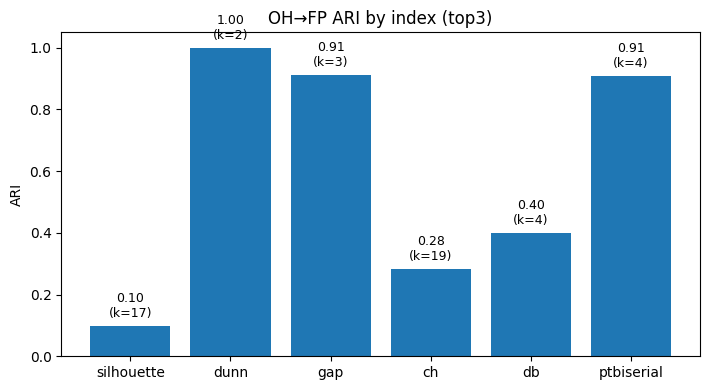

Saved: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/plots/FigA_ARI_top3.png | /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/plots/FigA_ARI_top3.pdf


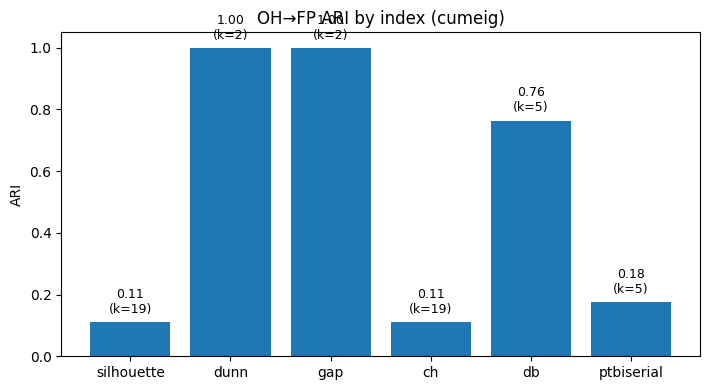

Saved: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/plots/FigA_ARI_cumeig.png | /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/plots/FigA_ARI_cumeig.pdf


In [14]:
for metric in ["ARI"]:  # 必要なら ["ARI","NMI","AMI"] で拡張
    for md in mode_order:
        sub = ohfp[ohfp["mode"]==md].sort_values("index")
        x = np.arange(len(index_order))
        y = sub.set_index("index")[metric].reindex(index_order).values
        kB = sub.set_index("index")["kB_FP"].reindex(index_order).values  # FP側のkを棒上に注記

        plt.figure(figsize=(7.2,4.0))
        plt.bar(x, y)
        for i,(val, kb) in enumerate(zip(y, kB)):
            if np.isfinite(val):
                plt.text(i, val+(0.02 if val>=0 else 0.02), f"{val:.2f}\n(k={int(kb) if np.isfinite(kb) else 'NA'})",
                         ha="center", va="bottom", fontsize=9)
        plt.xticks(x, index_order, rotation=0)
        plt.ylim(0, 1.05)
        plt.ylabel(metric)
        plt.title(f"OH→FP {metric} by index ({md})")
        plt.tight_layout()

        png = out_dir / f"FigA_{metric}_{md}.png"
        pdf = out_dir / f"FigA_{metric}_{md}.pdf"
        plt.savefig(png, dpi=300)
        plt.savefig(pdf)
        plt.show()
        print("Saved:", png, "|", pdf)

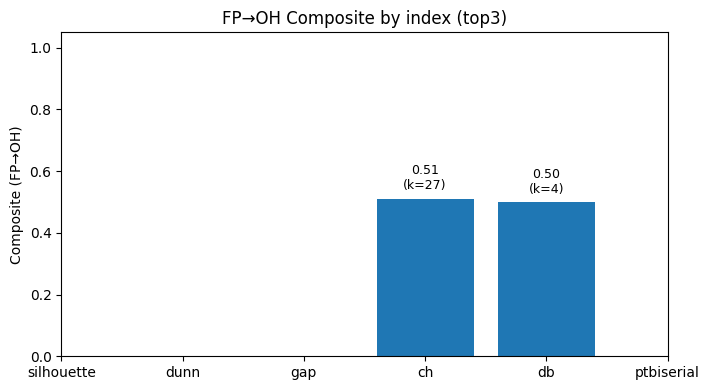

Saved: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/plots/FigB_composite_top3.png | /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/plots/FigB_composite_top3.pdf


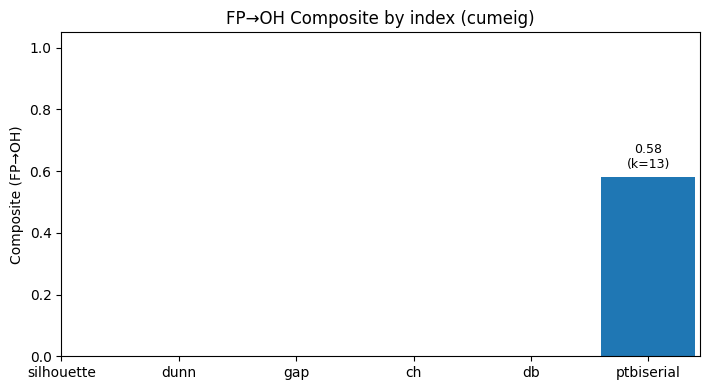

Saved: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/plots/FigB_composite_cumeig.png | /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/plots/FigB_composite_cumeig.pdf


In [15]:
for md in mode_order:
    sub_m = merged[merged["mode"]==md].sort_values("index")
    x = np.arange(len(index_order))
    y = sub_m.set_index("index")["composite"].reindex(index_order).values
    kA = sub_m.set_index("index")["kA_OH"].reindex(index_order).values  # OH側のkを注記

    plt.figure(figsize=(7.2,4.0))
    plt.bar(x, y)
    for i,(val, ka) in enumerate(zip(y, kA)):
        if np.isfinite(val):
            plt.text(i, val+(0.02 if val>=0 else 0.02), f"{val:.2f}\n(k={int(ka) if np.isfinite(ka) else 'NA'})",
                     ha="center", va="bottom", fontsize=9)
    plt.xticks(x, index_order, rotation=0)
    plt.ylim(0, 1.05)
    plt.ylabel("Composite (FP→OH)")
    plt.title(f"FP→OH Composite by index ({md})")
    plt.tight_layout()

    png = out_dir / f"FigB_composite_{md}.png"
    pdf = out_dir / f"FigB_composite_{md}.pdf"
    plt.savefig(png, dpi=300)
    plt.savefig(pdf)
    plt.show()
    print("Saved:", png, "|", pdf)

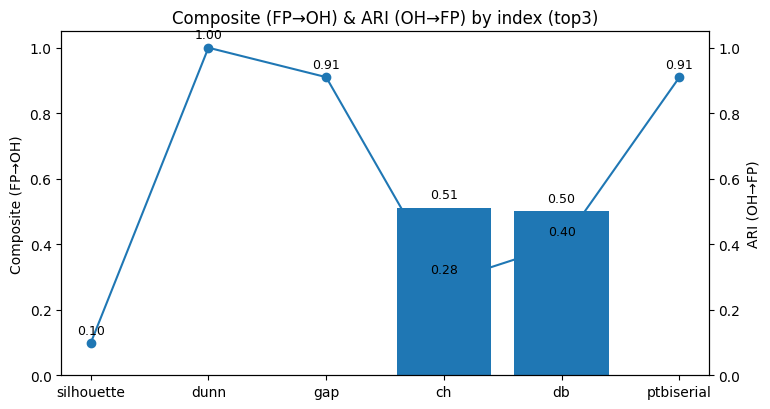

Saved: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/plots/FigC_composite_plus_ARI_top3.png | /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/plots/FigC_composite_plus_ARI_top3.pdf


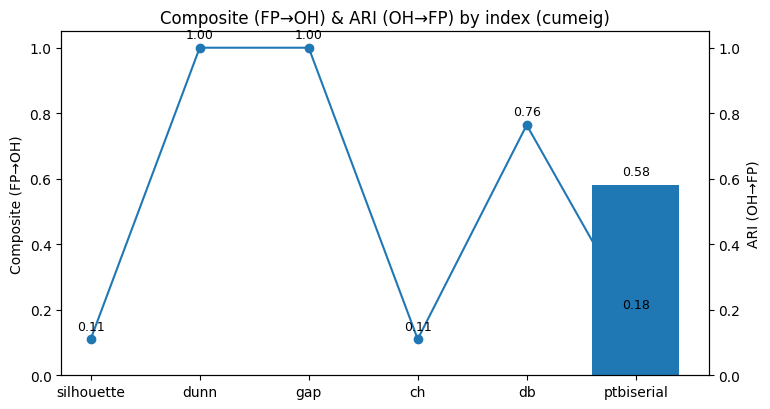

Saved: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/plots/FigC_composite_plus_ARI_cumeig.png | /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/plots/FigC_composite_plus_ARI_cumeig.pdf


In [16]:
for md in mode_order:
    sub = merged[merged["mode"]==md].sort_values("index")
    x_labels = list(sub["index"].astype(str))
    x = np.arange(len(x_labels))

    comp = sub["composite"].values
    ari  = sub["ARI"].values

    fig, ax1 = plt.subplots(figsize=(7.8,4.2))
    ax1.bar(x, comp)
    ax1.set_ylabel("Composite (FP→OH)")
    ax1.set_ylim(0, 1.05)

    ax2 = ax1.twinx()
    ax2.plot(x, ari, marker="o")
    ax2.set_ylabel("ARI (OH→FP)")
    ax2.set_ylim(0, 1.05)

    ax1.set_xticks(x)
    ax1.set_xticklabels(x_labels)
    ax1.set_title(f"Composite (FP→OH) & ARI (OH→FP) by index ({md})")

    # ラベル数値
    for i,(c,a) in enumerate(zip(comp, ari)):
        if np.isfinite(c):
            ax1.text(i, c+(0.02 if c>=0 else 0.02), f"{c:.2f}", ha="center", va="bottom", fontsize=9)
        if np.isfinite(a):
            ax2.text(i, a+(0.02 if a>=0 else 0.02), f"{a:.2f}", ha="center", va="bottom", fontsize=9)

    fig.tight_layout()
    png = out_dir / f"FigC_composite_plus_ARI_{md}.png"
    pdf = out_dir / f"FigC_composite_plus_ARI_{md}.pdf"
    plt.savefig(png, dpi=300)
    plt.savefig(pdf)
    plt.show()
    print("Saved:", png, "|", pdf)

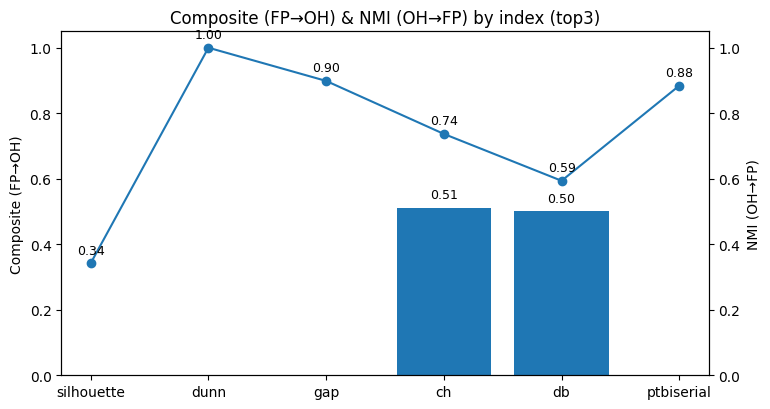

Saved: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/plots/FigD_composite_plus_NMI_top3.png | /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/plots/FigD_composite_plus_NMI_top3.pdf


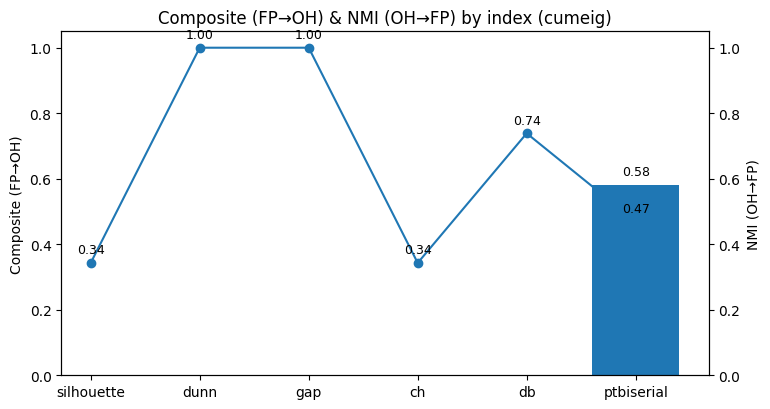

Saved: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/plots/FigD_composite_plus_NMI_cumeig.png | /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/plots/FigD_composite_plus_NMI_cumeig.pdf


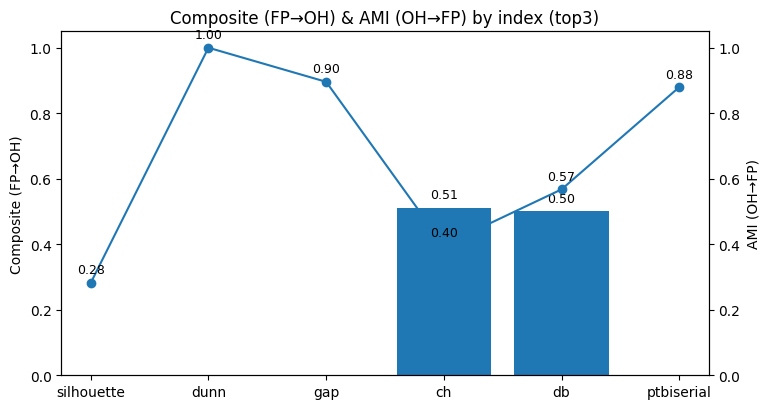

Saved: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/plots/FigD_composite_plus_AMI_top3.png | /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/plots/FigD_composite_plus_AMI_top3.pdf


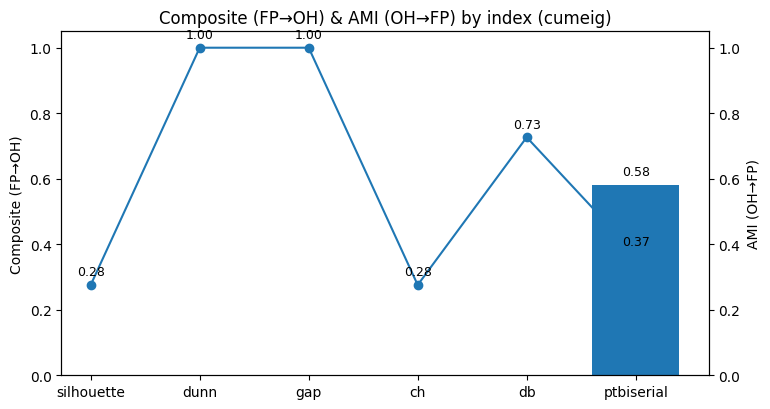

Saved: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/plots/FigD_composite_plus_AMI_cumeig.png | /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/plots/FigD_composite_plus_AMI_cumeig.pdf


In [17]:
right_metrics = ["NMI","AMI"]  # どちらも出力
for rm in right_metrics:
    for md in mode_order:
        sub = merged[merged["mode"]==md].sort_values("index")
        x_labels = list(sub["index"].astype(str))
        x = np.arange(len(x_labels))

        comp = sub["composite"].values
        right = sub[rm].values

        fig, ax1 = plt.subplots(figsize=(7.8,4.2))
        ax1.bar(x, comp)
        ax1.set_ylabel("Composite (FP→OH)")
        ax1.set_ylim(0, 1.05)

        ax2 = ax1.twinx()
        ax2.plot(x, right, marker="o")
        ax2.set_ylabel(rm + " (OH→FP)")
        ax2.set_ylim(0, 1.05)

        ax1.set_xticks(x)
        ax1.set_xticklabels(x_labels)
        ax1.set_title(f"Composite (FP→OH) & {rm} (OH→FP) by index ({md})")

        for i,(c,a) in enumerate(zip(comp, right)):
            if np.isfinite(c):
                ax1.text(i, c+(0.02 if c>=0 else 0.02), f"{c:.2f}", ha="center", va="bottom", fontsize=9)
            if np.isfinite(a):
                ax2.text(i, a+(0.02 if a>=0 else 0.02), f"{a:.2f}", ha="center", va="bottom", fontsize=9)

        fig.tight_layout()
        png = out_dir / f"FigD_composite_plus_{rm}_{md}.png"
        pdf = out_dir / f"FigD_composite_plus_{rm}_{md}.pdf"
        plt.savefig(png, dpi=300)
        plt.savefig(pdf)
        plt.show()
        print("Saved:", png, "|", pdf)

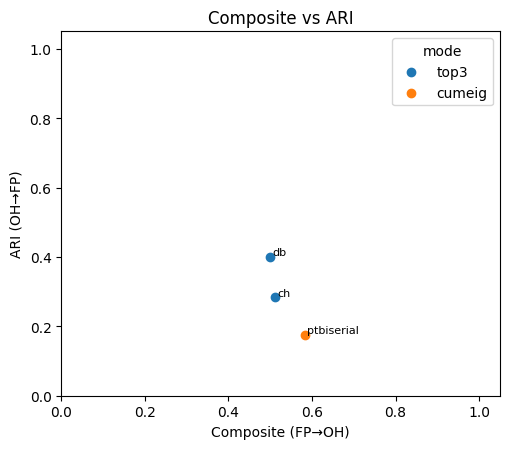

Saved: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/plots/Scatter_composite_vs_ARI.png | /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/plots/Scatter_composite_vs_ARI.pdf


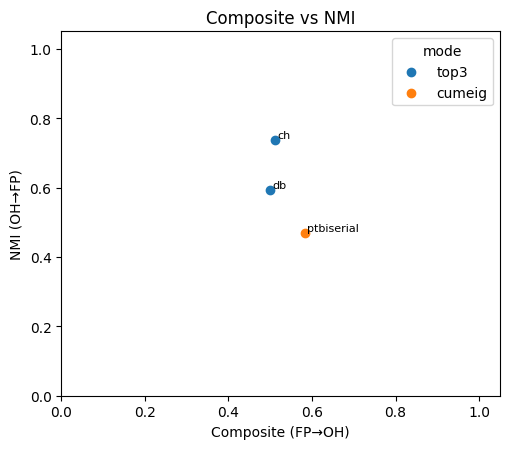

Saved: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/plots/Scatter_composite_vs_NMI.png | /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/plots/Scatter_composite_vs_NMI.pdf


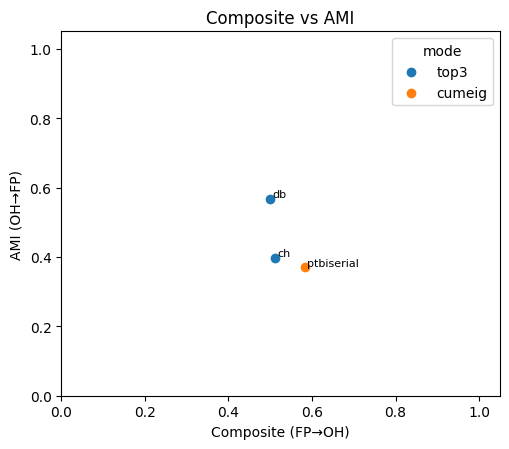

Saved: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/plots/Scatter_composite_vs_AMI.png | /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters/STEP3.3_U25_20251027_correct/plots/Scatter_composite_vs_AMI.pdf


In [18]:
pairs = [("ARI","Composite vs ARI"), ("NMI","Composite vs NMI"), ("AMI","Composite vs AMI")]
for (m,title) in pairs:
    plt.figure(figsize=(5.2,4.6))
    for md in mode_order:
        sub = merged[merged["mode"]==md]
        plt.scatter(sub["composite"], sub[m], label=md)
        for _,r in sub.iterrows():
            plt.text(r["composite"]+0.005, r[m]+0.005, r["index"], fontsize=8)
    plt.xlabel("Composite (FP→OH)")
    plt.ylabel(m + " (OH→FP)")
    plt.xlim(0,1.05); plt.ylim(0,1.05)
    plt.legend(title="mode")
    plt.title(title)
    plt.tight_layout()
    png = out_dir / f"Scatter_composite_vs_{m}.png"
    pdf = out_dir / f"Scatter_composite_vs_{m}.pdf"
    plt.savefig(png, dpi=300)
    plt.savefig(pdf)
    plt.show()
    print("Saved:", png, "|", pdf)

In [19]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 入力パス（前セルと同じ）
base_dir = Path("/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No")
run_root = base_dir / "20251026_under_25clusters" / "STEP3.3_U25_20251027_correct"
in_metrics = run_root / "plots_var" / "metrics_ohfp_by_mode_index.csv"
in_rev_all = run_root / "paper_4.2.4.4_OHFP" / "reverse" / "analysis_csv" / "Table_4.2.4.4R_ALL_summary.csv"
out_dir = run_root / "plots"
out_dir.mkdir(parents=True, exist_ok=True)

# 読み込みと整形
ohfp = pd.read_csv(in_metrics)
rev  = pd.read_csv(in_rev_all)
index_order = ["silhouette","dunn","gap","ch","db","ptbiserial"]
mode_order  = ["top3","cumeig"]
for df in (ohfp, rev):
    df["index"] = pd.Categorical(df["index"].astype(str), categories=index_order, ordered=True)
    df["mode"]  = pd.Categorical(df["mode"].astype(str),  categories=mode_order,  ordered=True)

merged = pd.merge(
    ohfp[["mode","index","ARI","NMI","AMI","kA_OH","kB_FP"]],
    rev[["mode","index","composite"]],
    on=["mode","index"], how="inner"
).sort_values(["mode","index"])

# 体裁（論文向け）
plt.rcParams.update({
    "figure.figsize": (7.5, 4.2),
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})